In [1]:
import sys
import subprocess
import pkgutil

required = ["pandas","numpy","matplotlib","seaborn","statsmodels","lightgbm","scikit-learn","kaggle"]
for pkg in required:
    if not pkgutil.find_loader(pkg):
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

/tmp/ipykernel_2698/761722200.py:7: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if not pkgutil.find_loader(pkg):


Installing scikit-learn ...


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [8]:
!pip install prophet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
from google.colab import files

uploaded = files.upload()

In [5]:
df = pd.read_csv("train.csv")

print(df.head())

print(df.info())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0          0.0
1   1  2013-01-01          1   BABY CARE    0.0          0.0
2   2  2013-01-01          1      BEAUTY    0.0          0.0
3   3  2013-01-01          1   BEVERAGES    0.0          0.0
4   4  2013-01-01          1       BOOKS    0.0          0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033292 entries, 0 to 1033291
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1033292 non-null  int64  
 1   date         1033292 non-null  object 
 2   store_nbr    1033292 non-null  int64  
 3   family       1033292 non-null  object 
 4   sales        1033291 non-null  float64
 5   onpromotion  1033291 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 47.3+ MB
None


In [6]:
# Convert date

df['date'] = pd.to_datetime(df['date'])

# Remove missing values

df = df.dropna()

# Sort by date

df = df.sort_values('date')

In [7]:
store = 1
family = "AUTOMOTIVE"

sales = df[
    (df['store_nbr']==store) &
    (df['family']==family)
]

sales = sales[['date','sales']]

sales.columns = ['ds','y']

print(sales.head())

             ds    y
0    2013-01-01  0.0
1782 2013-01-02  2.0
3564 2013-01-03  3.0
5346 2013-01-04  3.0
7128 2013-01-05  5.0


In [9]:
store = 1
family = "AUTOMOTIVE"

sales = df[
    (df['store_nbr']==store) &
    (df['family']==family)
]

sales = sales[['date','sales']]

sales.columns = ['ds','y']

print(sales.head())

             ds    y
0    2013-01-01  0.0
1782 2013-01-02  2.0
3564 2013-01-03  3.0
5346 2013-01-04  3.0
7128 2013-01-05  5.0


In [10]:
sales['Year'] = sales['ds'].dt.year
sales['Month'] = sales['ds'].dt.month
sales['Day'] = sales['ds'].dt.day
sales['Weekday'] = sales['ds'].dt.day_name()

sales.head()

,ds,y,Year,Month,Day,Weekday
0,2013-01-01,0.0,2013,1,1,Tuesday
1782,2013-01-02,2.0,2013,1,2,Wednesday
3564,2013-01-03,3.0,2013,1,3,Thursday
5346,2013-01-04,3.0,2013,1,4,Friday
7128,2013-01-05,5.0,2013,1,5,Saturday


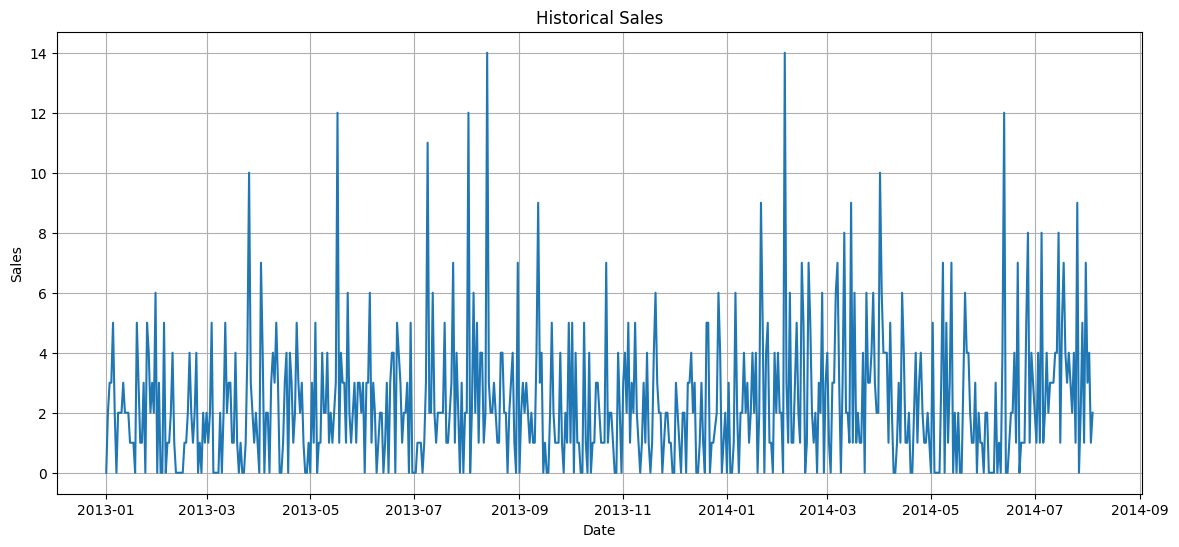

In [11]:
plt.figure(figsize=(14,6))

plt.plot(sales['ds'],sales['y'])

plt.title("Historical Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [12]:
train = sales[:-90]

test = sales[-90:]

In [14]:
from prophet import Prophet

model = Prophet()

model.fit(train[['ds','y']])

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [15]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

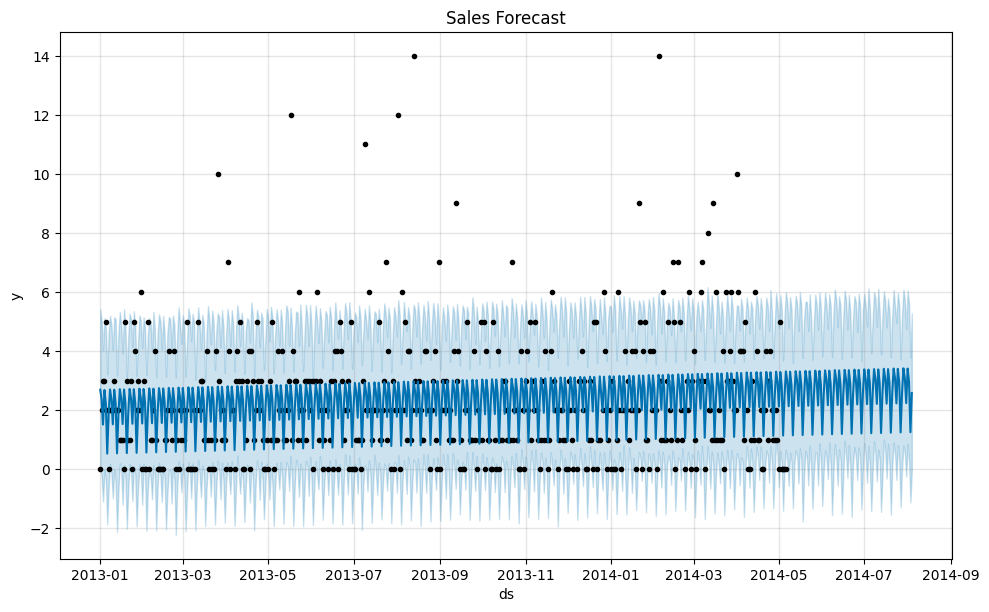

In [16]:
model.plot(forecast)

plt.title("Sales Forecast")

plt.show()

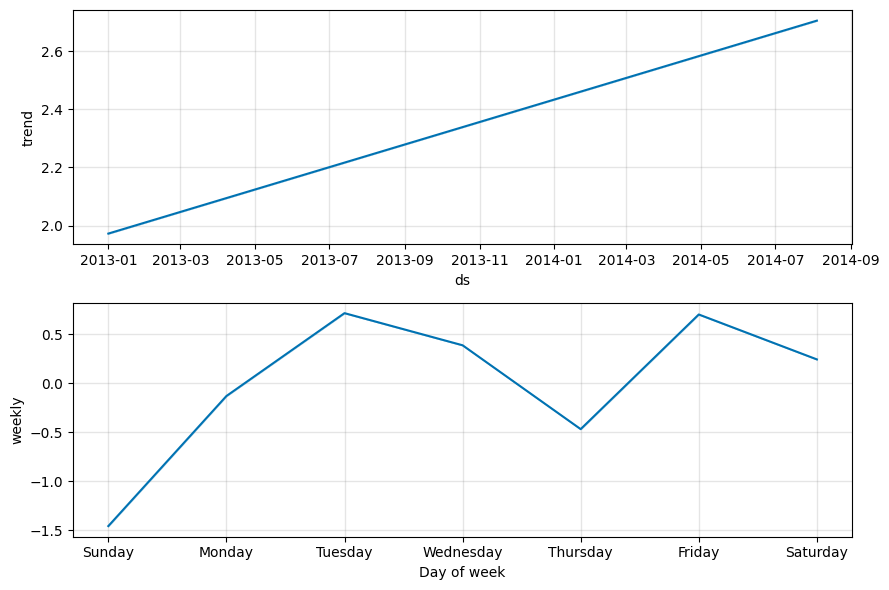

In [17]:
model.plot_components(forecast)

plt.show()

In [18]:
prediction = forecast[['ds','yhat']]

evaluation = test.merge(prediction,on='ds')

mae = mean_absolute_error(
    evaluation['y'],
    evaluation['yhat']
)

rmse = np.sqrt(
    mean_squared_error(
        evaluation['y'],
        evaluation['yhat']
    )
)

mape = np.mean(
    np.abs(
        (evaluation['y']-evaluation['yhat'])
        /
        evaluation['y']
    )
)*100

print("MAE :",mae)

print("RMSE:",rmse)

print("MAPE:",mape,"%")

MAE : 1.9386064847606457
RMSE: 2.439832776303555
MAPE: inf %


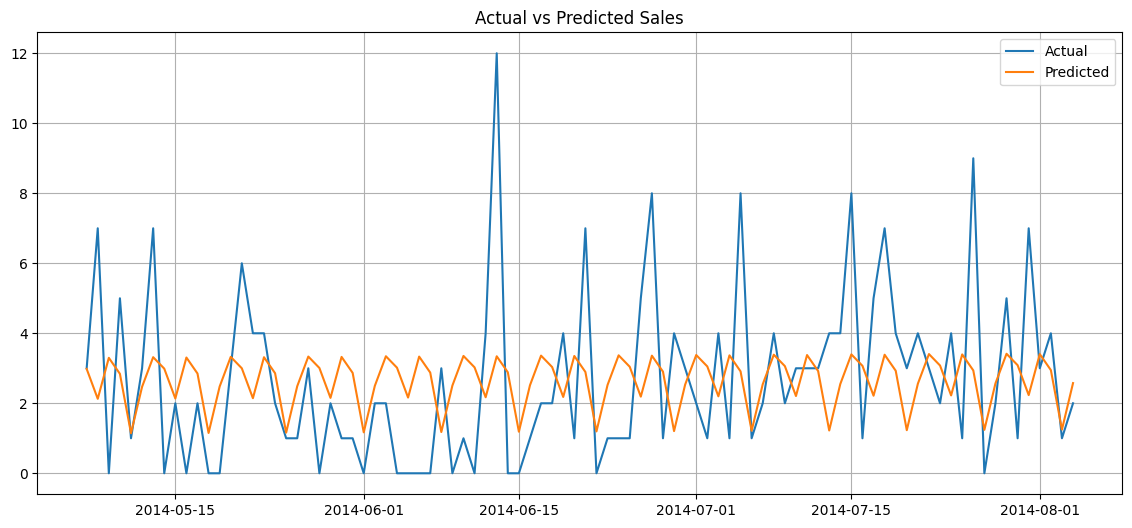

In [19]:
plt.figure(figsize=(14,6))

plt.plot(
    evaluation['ds'],
    evaluation['y'],
    label="Actual"
)

plt.plot(
    evaluation['ds'],
    evaluation['yhat'],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.grid(True)

plt.show()

In [20]:
future180 = model.make_future_dataframe(periods=180)

forecast180 = model.predict(future180)

forecast180[['ds','yhat']].tail()

,ds,yhat
665,2014-10-29,3.203061
666,2014-10-30,2.349088
667,2014-10-31,3.519749
668,2014-11-01,3.062932
669,2014-11-02,1.364091


In [21]:
forecast180[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    "Sales_Forecast.csv",
    index=False
)

print("Forecast saved Successfully")

Forecast saved Successfully


In [22]:
print("Business Insights")

print("- Historical sales trend analyzed.")

print("- Future sales forecast generated.")

print("- Trend and seasonality identified.")

print("- Forecast can help inventory planning.")

print("- Useful for production and staffing decisions.")

Business Insights
- Historical sales trend analyzed.
- Future sales forecast generated.
- Trend and seasonality identified.
- Forecast can help inventory planning.
- Useful for production and staffing decisions.
